In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = r"C:\Users\kaija\Downloads\Task 3 and 4_Loan_Data.csv"

In [2]:
def load_fico_data(path=DATA_PATH):
    df = pd.read_csv(path)[["fico_score", "default"]]
    df = df.dropna().sort_values("fico_score").reset_index(drop=True)
    return df

In [3]:
def _build_cumulative_tables(df):
    """
    Returns arrays of sorted unique FICO scores plus cumulative
    total-count and default-count arrays for O(1) range lookups.
    """
    scores  = df["fico_score"].values
    defaults = df["default"].values

    min_score = int(scores.min())
    max_score = int(scores.max())
    score_range = np.arange(min_score, max_score + 1)

    # Vectorised count per integer FICO value
    n_per_score = np.zeros(len(score_range), dtype=int)
    k_per_score = np.zeros(len(score_range), dtype=int)

    for s, d in zip(scores, defaults):
        idx = int(s) - min_score
        n_per_score[idx] += 1
        k_per_score[idx] += int(d)

    cum_n = np.cumsum(n_per_score)
    cum_k = np.cumsum(k_per_score)

    return score_range, cum_n, cum_k, min_score

In [4]:
def _bucket_ll(cum_n, cum_k, l, r):
    """
    Log-likelihood contribution for the bucket covering
    score_range indices [l, r] (inclusive).
    Returns 0 if bucket is pure (no variation to model).
    """
    n = cum_n[r] - (cum_n[l - 1] if l > 0 else 0)
    k = cum_k[r] - (cum_k[l - 1] if l > 0 else 0)

    if n == 0 or k == 0 or k == n:
        return 0.0

    p = k / n
    return k * np.log(p) + (n - k) * np.log(1 - p)


In [5]:
def find_optimal_boundaries(df, n_buckets):
    """
    Find the n_buckets-1 boundary points that maximise total log-likelihood
    across all buckets using bottom-up dynamic programming.

    Parameters
    ----------
    df        : DataFrame with columns fico_score, default
    n_buckets : int — number of buckets to partition FICO scores into

    Returns
    -------
    boundaries : list of ints — the (n_buckets - 1) cut points between buckets
    total_ll   : float — the achieved log-likelihood
    """
    score_range, cum_n, cum_k, min_score = _build_cumulative_tables(df)
    M = len(score_range)  # number of distinct integer FICO values

    # dp[b][i] = best LL using exactly b buckets for score indices 0..i
    # split[b][i] = left index of last bucket when dp[b][i] is achieved
    NEG_INF = -1e18
    dp    = [[NEG_INF] * M for _ in range(n_buckets + 1)]
    split = [[0]        * M for _ in range(n_buckets + 1)]

    # Base: 1 bucket covering 0..i
    for i in range(M):
        dp[1][i]    = _bucket_ll(cum_n, cum_k, 0, i)
        split[1][i] = 0

    # Fill DP table
    for b in range(2, n_buckets + 1):
        for i in range(b - 1, M):
            best_ll  = NEG_INF
            best_cut = b - 1
            for j in range(b - 1, i + 1):
                prev = dp[b - 1][j - 1] if j > 0 else 0.0
                ll   = prev + _bucket_ll(cum_n, cum_k, j, i)
                if ll > best_ll:
                    best_ll  = ll
                    best_cut = j
            dp[b][i]    = best_ll
            split[b][i] = best_cut

    # Backtrack to recover bucket boundaries
    boundaries = []
    i = M - 1
    for b in range(n_buckets, 1, -1):
        j = split[b][i]
        if j > 0:
            boundaries.append(int(score_range[j]))
        i = j - 1

    boundaries = sorted(boundaries)
    total_ll   = dp[n_buckets][M - 1]
    return boundaries, total_ll


In [6]:
def find_optimal_n_buckets(df, max_buckets=20):
    """
    Run the DP for 2..max_buckets and return a DataFrame with
    LL, AIC (penalised LL), and marginal LL gain per bucket count.
    AIC = -2*LL + 2*(n_buckets - 1)  [penalises extra boundaries]
    """
    results = []
    for n in range(2, max_buckets + 1):
        _, ll = find_optimal_boundaries(df, n)
        aic   = -2 * ll + 2 * (n - 1)
        results.append({"n_buckets": n, "log_likelihood": ll, "aic": aic})

    out = pd.DataFrame(results)
    out["marginal_ll"] = out["log_likelihood"].diff().fillna(0)
    return out

In [7]:
def build_rating_map(df, n_buckets=10):
    """
    Returns the boundary list and bucket metadata for the optimal partition.

    Rating 1 = best credit (highest FICO), Rating N = worst credit.
    """
    boundaries, total_ll = find_optimal_boundaries(df, n_buckets)
    score_range, cum_n, cum_k, min_score = _build_cumulative_tables(df)
    M = len(score_range)

    # Reconstruct bucket ranges from boundaries
    cut_indices = [0] + [b - min_score for b in boundaries] + [M]
    buckets = []
    for i in range(len(cut_indices) - 1):
        l = cut_indices[i]
        r = cut_indices[i + 1] - 1
        n = cum_n[r] - (cum_n[l - 1] if l > 0 else 0)
        k = cum_k[r] - (cum_k[l - 1] if l > 0 else 0)
        buckets.append({
            "fico_low":  int(score_range[l]),
            "fico_high": int(score_range[r]),
            "n":         int(n),
            "defaults":  int(k),
            "pd":        round(k / n, 4) if n > 0 else 0.0,
        })

    # Assign ratings: highest FICO bucket = Rating 1 (best)
    buckets_df = pd.DataFrame(buckets).sort_values("fico_low", ascending=False).reset_index(drop=True)
    buckets_df["rating"] = range(1, n_buckets + 1)
    buckets_df = buckets_df.sort_values("fico_low", ascending=True).reset_index(drop=True)

    return buckets_df, boundaries, total_ll

In [8]:
_cached_map: pd.DataFrame = None
_cached_n:   int          = None

def get_rating(fico_score, n_buckets=10, df=None, force_rebuild=False):
    """
    Map a FICO score to a credit rating bucket.

    Parameters
    ----------
    fico_score    : int or float — FICO score of the borrower (300-850)
    n_buckets     : int — number of rating buckets (default 10)
    df            : DataFrame — supply your own data to retrain; defaults to
                    the portfolio dataset at DATA_PATH
    force_rebuild : bool — force recompute even if cache is valid

    Returns
    -------
    dict:
        rating     — int (1 = best credit, n_buckets = worst)
        fico_range — (low, high) tuple for the assigned bucket
        bucket_pd  — historical default rate for this bucket
    """
    global _cached_map, _cached_n

    if df is None:
        df = load_fico_data()

    if force_rebuild or _cached_map is None or _cached_n != n_buckets:
        _cached_map, _, _ = build_rating_map(df, n_buckets)
        _cached_n = n_buckets

    score = float(fico_score)
    for _, row in _cached_map.iterrows():
        if row["fico_low"] <= score <= row["fico_high"]:
            return {
                "rating":     int(row["rating"]),
                "fico_range": (int(row["fico_low"]), int(row["fico_high"])),
                "bucket_pd":  float(row["pd"]),
            }

    raise ValueError(f"FICO score {fico_score} outside observed range "
                     f"({int(_cached_map['fico_low'].min())}–{int(_cached_map['fico_high'].max())})")

In [9]:
def plot_bucketing(df, n_buckets=10, optimality_df=None):
    buckets_df, boundaries, _ = build_rating_map(df, n_buckets)

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    fig.suptitle("FICO Score Bucketing — Log-Likelihood Optimisation", fontsize=14, fontweight="bold")

    # ── Panel 1: Optimal n_buckets (LL and AIC) ───────────────────────────────
    ax1 = axes[0, 0]
    if optimality_df is not None:
        ax1b = ax1.twinx()
        ax1.plot(optimality_df["n_buckets"], optimality_df["log_likelihood"],
                 "o-", color="#2e86de", linewidth=2, label="Log-likelihood")
        ax1b.plot(optimality_df["n_buckets"], optimality_df["aic"],
                  "s--", color="#e84118", linewidth=2, label="AIC (lower = better)")
        best_n = int(optimality_df.loc[optimality_df["aic"].idxmin(), "n_buckets"])
        ax1.axvline(best_n, color="green", linestyle=":", linewidth=1.5,
                    label=f"AIC optimal n={best_n}")
        ax1.axvline(n_buckets, color="purple", linestyle=":", linewidth=1.5,
                    label=f"Selected n={n_buckets}")
        ax1.set_xlabel("Number of Buckets")
        ax1.set_ylabel("Log-Likelihood", color="#2e86de")
        ax1b.set_ylabel("AIC", color="#e84118")
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax1b.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
    ax1.set_title("LL & AIC vs Number of Buckets", fontsize=11)
    ax1.grid(alpha=0.3)

    # ── Panel 2: FICO distribution with bucket boundaries ────────────────────
    ax2 = axes[0, 1]
    ax2.hist(df["fico_score"], bins=60, color="#2e86de", alpha=0.7, edgecolor="white")
    for b in boundaries:
        ax2.axvline(b, color="#e84118", linestyle="--", linewidth=1.2, alpha=0.8)
    ax2.set_title(f"FICO Score Distribution with {n_buckets} Optimal Buckets", fontsize=11)
    ax2.set_xlabel("FICO Score")
    ax2.set_ylabel("Count")
    ax2.grid(alpha=0.3)

    # ── Panel 3: Default rate per bucket ─────────────────────────────────────
    ax3 = axes[1, 0]
    colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(buckets_df)))
    labels = [f"R{int(r['rating'])}\n{int(r['fico_low'])}-{int(r['fico_high'])}"
              for _, r in buckets_df.sort_values("rating").iterrows()]
    pds    = buckets_df.sort_values("rating")["pd"].values
    bars   = ax3.bar(labels, pds, color=colors, edgecolor="white")
    for bar, val in zip(bars, pds):
        ax3.text(bar.get_x() + bar.get_width() / 2, val + 0.003,
                 f"{val:.1%}", ha="center", va="bottom", fontsize=8)
    ax3.set_title("Default Rate (PD) by Rating Bucket", fontsize=11)
    ax3.set_xlabel("Rating (1=Best)")
    ax3.set_ylabel("Probability of Default")
    ax3.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax3.grid(axis="y", alpha=0.3)

    # ── Panel 4: Bucket population ────────────────────────────────────────────
    ax4 = axes[1, 1]
    ns = buckets_df.sort_values("rating")["n"].values
    ax4.bar(labels, ns, color="#2e86de", alpha=0.8, edgecolor="white")
    for i, val in enumerate(ns):
        ax4.text(i, val + 5, str(val), ha="center", va="bottom", fontsize=8)
    ax4.set_title("Borrower Count per Bucket", fontsize=11)
    ax4.set_xlabel("Rating (1=Best)")
    ax4.set_ylabel("Number of Borrowers")
    ax4.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    out = r"C:\Users\kaija\quant research\fico_bucketing.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved to: {out}")


Loading data...
  10,000 borrowers | FICO range: 408–850
  Overall default rate: 18.5%

Scanning 2–20 buckets to find optimal n...
  AIC-optimal number of buckets: 20
  Selected: 10 buckets (as specified)

 n_buckets  log_likelihood         aic  marginal_ll
         2    -4419.163112 8840.326223     0.000000
         3    -4319.493970 8642.987940    99.669142
         4    -4276.732522 8559.465043    42.761448
         5    -4255.377391 8518.754783    21.355130
         6    -4239.869774 8489.739548    15.507617
         7    -4229.603238 8471.206477    10.266536
         8    -4224.307791 8462.615582     5.295447
         9    -4221.023500 8458.046999     3.284291
        10    -4217.824477 8453.648955     3.199022
        11    -4214.867350 8449.734701     2.957127
        12    -4211.849713 8445.699425     3.017638
        13    -4208.961613 8441.923226     2.888100
        14    -4205.943975 8437.887950     3.017638
        15    -4203.774479 8435.548959     2.169496
        16    

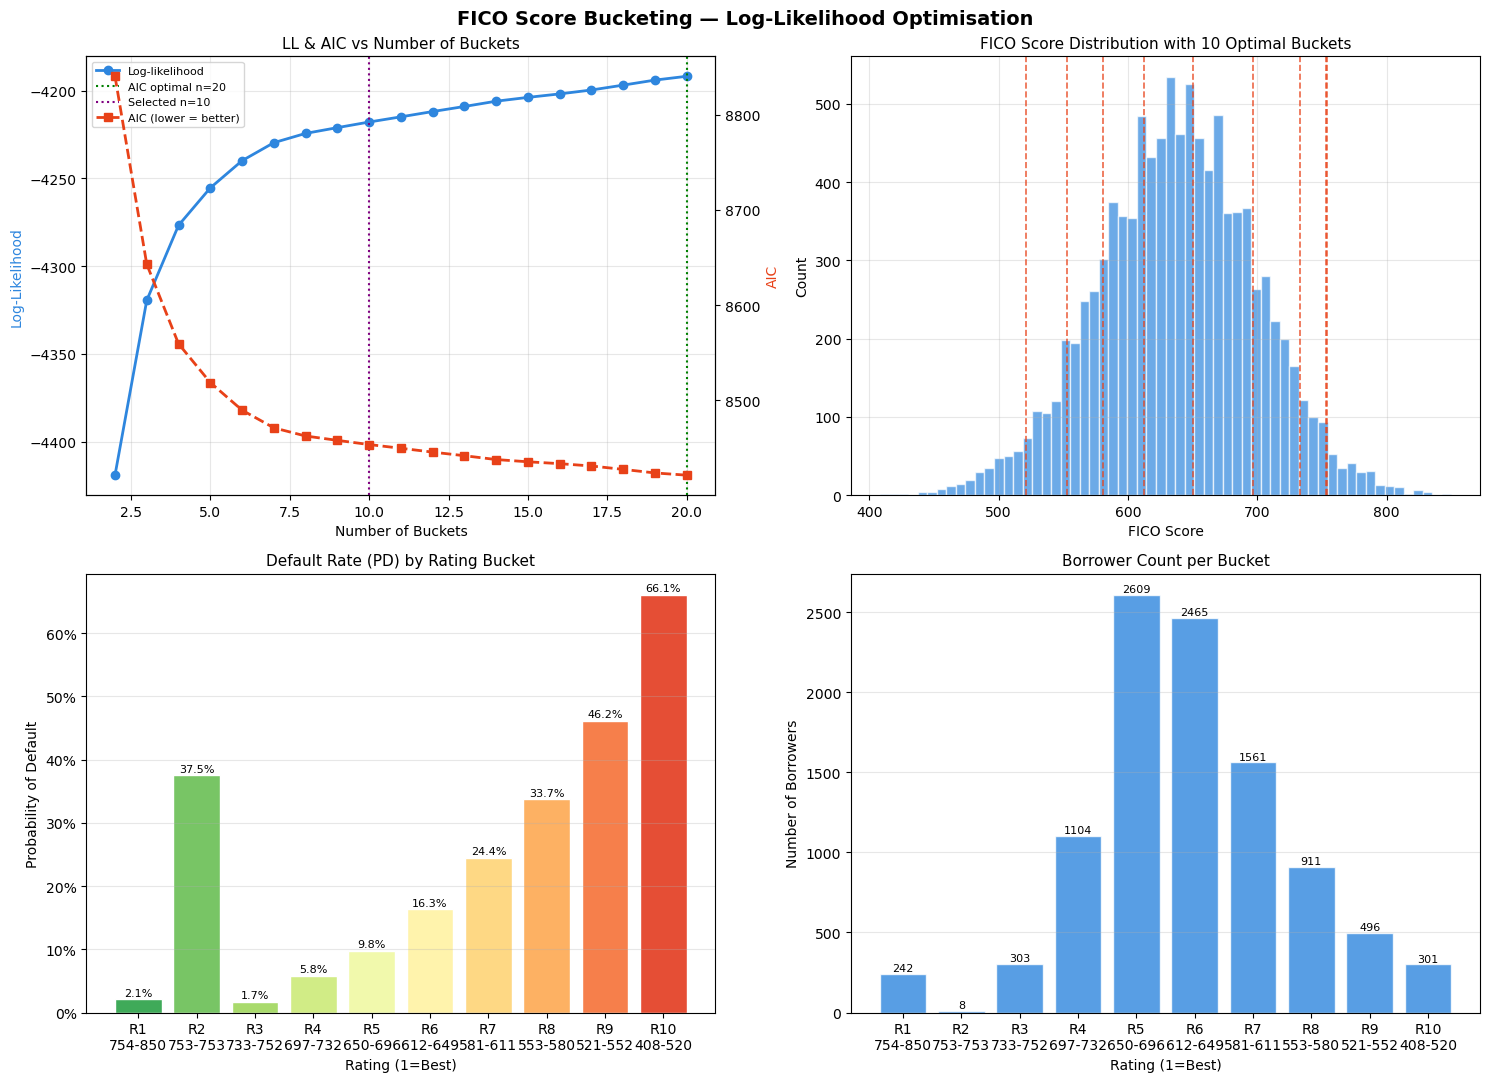

Plot saved to: C:\Users\kaija\quant research\fico_bucketing.png

  get_rating() DEMO
  FICO 420 -> Rating 10 | Range 408-520 | Bucket PD: 66.1%
  FICO 510 -> Rating 10 | Range 408-520 | Bucket PD: 66.1%
  FICO 570 -> Rating  8 | Range 553-580 | Bucket PD: 33.7%
  FICO 610 -> Rating  7 | Range 581-611 | Bucket PD: 24.4%
  FICO 640 -> Rating  6 | Range 612-649 | Bucket PD: 16.3%
  FICO 670 -> Rating  5 | Range 650-696 | Bucket PD: 9.8%
  FICO 700 -> Rating  4 | Range 697-732 | Bucket PD: 5.8%
  FICO 730 -> Rating  4 | Range 697-732 | Bucket PD: 5.8%
  FICO 780 -> Rating  1 | Range 754-850 | Bucket PD: 2.1%
  FICO 840 -> Rating  1 | Range 754-850 | Bucket PD: 2.1%


In [10]:
if __name__ == "__main__":
    print("Loading data...")
    df = load_fico_data()
    print(f"  {len(df):,} borrowers | FICO range: {df['fico_score'].min()}–{df['fico_score'].max()}")
    print(f"  Overall default rate: {df['default'].mean():.1%}\n")

    # Find optimal number of buckets
    print("Scanning 2–20 buckets to find optimal n...")
    opt_df = find_optimal_n_buckets(df, max_buckets=20)
    best_n = int(opt_df.loc[opt_df["aic"].idxmin(), "n_buckets"])
    print(f"  AIC-optimal number of buckets: {best_n}")
    print(f"  Selected: 10 buckets (as specified)\n")
    print(opt_df.to_string(index=False))

    # Build 10-bucket rating map
    print("\nBuilding 10-bucket rating map...")
    buckets_df, boundaries, total_ll = build_rating_map(df, n_buckets=10)
    print(f"  Optimal boundaries : {boundaries}")
    print(f"  Total log-likelihood: {total_ll:.4f}\n")

    print(buckets_df[["rating","fico_low","fico_high","n","defaults","pd"]].to_string(index=False))

    # Plot
    print("\nGenerating plots...")
    plot_bucketing(df, n_buckets=10, optimality_df=opt_df)

    # Demo get_rating()
    print("\n" + "=" * 52)
    print("  get_rating() DEMO")
    print("=" * 52)
    test_scores = [420, 510, 570, 610, 640, 670, 700, 730, 780, 840]
    for score in test_scores:
        r = get_rating(score, n_buckets=10)
        print(f"  FICO {score:3d} -> Rating {r['rating']:2d} "
              f"| Range {r['fico_range'][0]}-{r['fico_range'][1]} "
              f"| Bucket PD: {r['bucket_pd']:.1%}")